#📌 Extracão

In [2]:
from google.colab import files
uploaded = files.upload()

Saving TelecomX_Data.json to TelecomX_Data.json


In [3]:
from google.colab import files
uploaded = files.upload()

Saving TelecomX_dicionario.md to TelecomX_dicionario.md


In [4]:
import pandas as pd
import json

# Lendo o arquivo JSON
with open('TelecomX_Data.json', 'r') as f:
    dados_brutos = json.load(f)

# "Achatando" os dados aninhados para criar colunas claras
df = pd.json_normalize(dados_brutos)

# Visualizando as primeiras linhas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
# Convertendo a coluna Total para numérico (removendo espaços vazios se houver)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificando se há valores nulos após a conversão
print(df.isna().sum())

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


#🔧 Transformação

In [14]:
# Transformando a coluna de gasto total em numérica
# O errors='coerce' substitui o que não for número (como " ") por NaN
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificando quantos valores nulos foram gerados
print(f"Valores nulos em Total: {df['account.Charges.Total'].isna().sum()}")



Valores nulos em Total: 0


In [16]:
# Preenchendo nulos do Total com o valor mensal correspondente
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Monthly'])

# Removendo qualquer outra linha que ainda contenha dados nulos (se houver)
df.dropna(inplace=True)

In [17]:
# Cálculo do gasto diário médio (considerando o mês de 30 dias)
df['gasto_diario'] = df['account.Charges.Monthly'] / 30

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#📊 Carga e análise

### Resumo Estatístico das Variáveis Numéricas ###
       customer.tenure  account.Charges.Monthly  account.Charges.Total
count      7256.000000              7256.000000            7256.000000
mean         32.395535                64.755423            2280.634213
std          24.558067                30.125739            2268.632997
min           1.000000                18.250000              18.800000
25%           9.000000                35.450000             400.225000
50%          29.000000                70.300000            1391.000000
75%          55.000000                89.900000            3785.300000
max          72.000000               118.750000            8684.800000


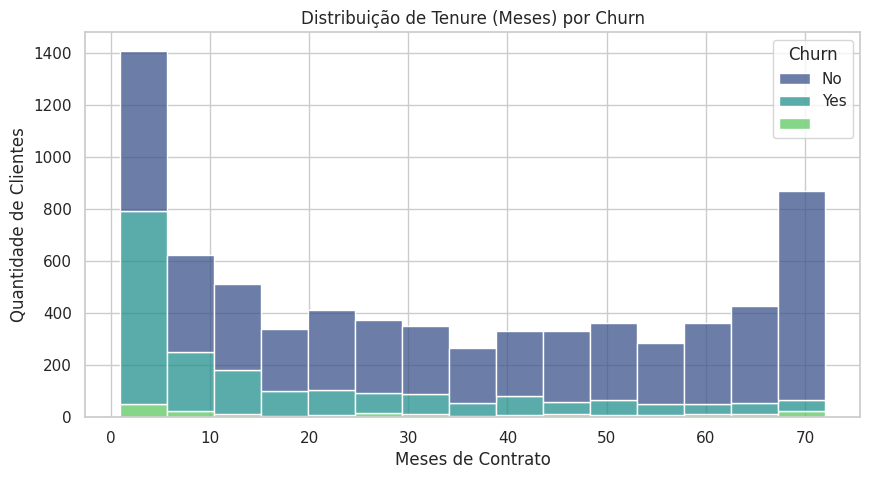

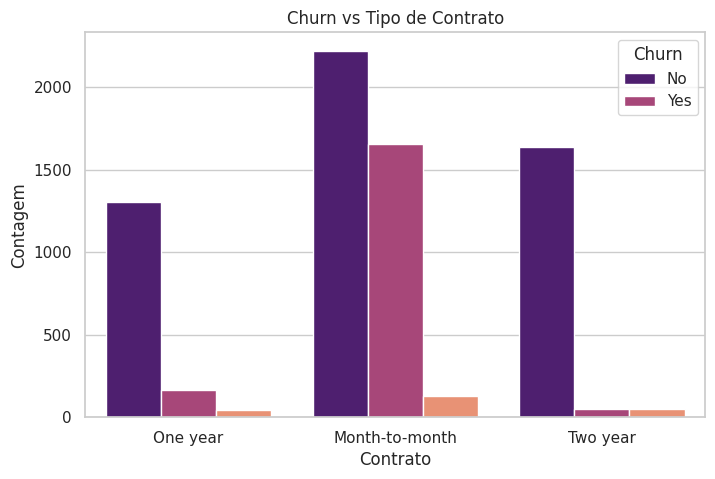

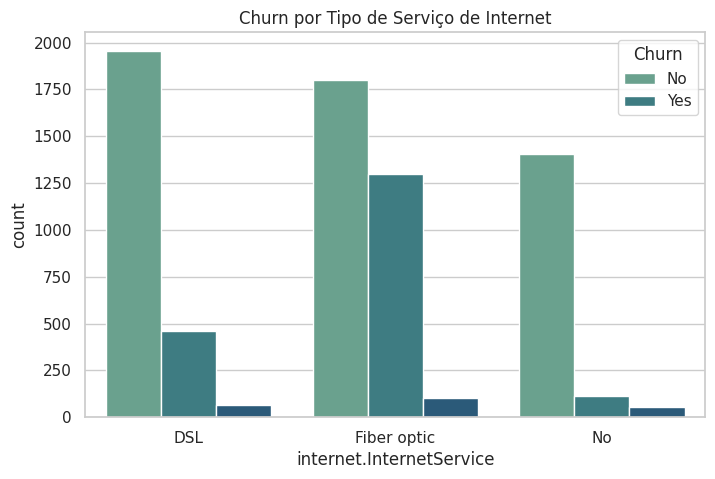

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

file_path = 'TelecomX_Data.json'

with open(file_path, 'r') as f:
    data = json.load(f)

df = pd.json_normalize(data)

df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df.dropna(inplace=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# --- ANÁLISE DESCRITIVA ---

print("### Resumo Estatístico das Variáveis Numéricas ###")
print(df[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].describe())

# 2. Visualização: Distribuição de Churn por Tempo de Contrato
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="customer.tenure", hue="Churn", multiple="stack", palette="viridis")
plt.title('Distribuição de Tenure (Meses) por Churn')
plt.xlabel('Meses de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

# 3. Visualização: Churn por Tipo de Contrato
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="account.Contract", hue="Churn", palette="magma")
plt.title('Churn vs Tipo de Contrato')
plt.xlabel('Contrato')
plt.ylabel('Contagem')
plt.show()

# 4. Visualização: Impacto do Serviço de Internet
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="internet.InternetService", hue="Churn", palette="crest")
plt.title('Churn por Tipo de Serviço de Internet')
plt.show()

In [22]:
# Resumo das variáveis numéricas
print("Resumo Estatístico:")
display(df[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].describe())

# Verificando a proporção de Churn
print("\nProporção de Churn (Evasão):")
print(df['Churn'].value_counts(normalize=True) * 100)

Resumo Estatístico:


,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213
std,24.558067,30.125739,2268.632997
min,1.000000,18.250000,18.800000
25%,9.000000,35.450000,400.225000
50%,29.000000,70.300000,1391.000000
75%,55.000000,89.900000,3785.300000
max,72.000000,118.750000,8684.800000



Proporção de Churn (Evasão):
Churn
No     71.154906
Yes    25.757993
        3.087100
Name: proportion, dtype: float64


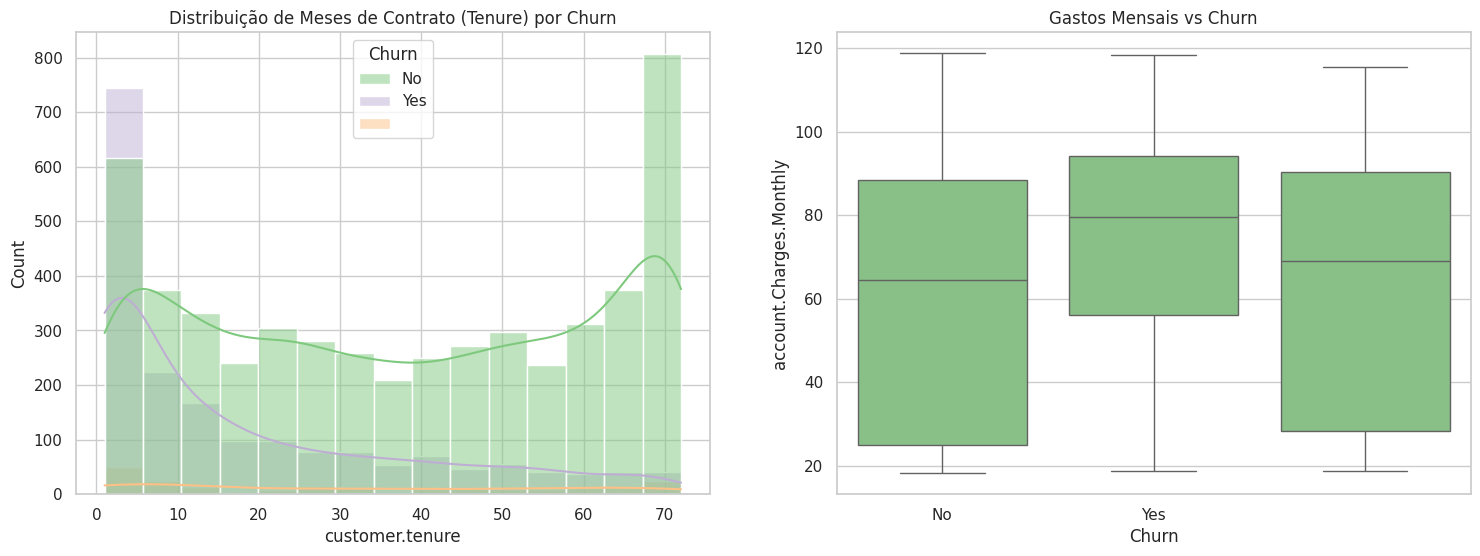

In [24]:
# Configurar o estilo
sns.set_palette("Accent")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Histograma de Tenure por Churn
sns.histplot(data=df, x="customer.tenure", hue="Churn", kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Meses de Contrato (Tenure) por Churn')

# Gráfico 2: Boxplot de Gastos Mensais por Churn
sns.boxplot(data=df, x="Churn", y="account.Charges.Monthly", ax=axes[1])
axes[1].set_title('Gastos Mensais vs Churn')

plt.show()

In [25]:
# Resumo das variáveis numéricas
print("Resumo Estatístico:")
display(df[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].describe())

# Verificando a proporção de Churn
print("\nProporção de Churn (Evasão):")
print(df['Churn'].value_counts(normalize=True) * 100)

Resumo Estatístico:


,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213
std,24.558067,30.125739,2268.632997
min,1.000000,18.250000,18.800000
25%,9.000000,35.450000,400.225000
50%,29.000000,70.300000,1391.000000
75%,55.000000,89.900000,3785.300000
max,72.000000,118.750000,8684.800000



Proporção de Churn (Evasão):
Churn
No     71.154906
Yes    25.757993
        3.087100
Name: proportion, dtype: float64


#📄Relatorio Final

Este relatório apresenta uma análise descritiva detalhada dos dados da **TelecomX**, estruturado para ser apresentado como uma documentação de projeto ou análise de negócio.

---

# Relatório de Análise Descritiva: TelecomX

**Data:** 9 de Março de 2026

**Objetivo:** Compreender o perfil dos clientes e identificar padrões comportamentais relacionados à rotatividade (Churn).

---

## 1. Visão Geral da Base de Dados

A base de dados é composta por informações de clientes que incluem dados demográficos, serviços contratados, detalhes financeiros e o status de cancelamento (Churn).

* **Variáveis Quantitativas Principais:** Tempo de contrato (`tenure`), cobrança mensal (`Monthly Charges`) e cobrança total (`Total Charges`).
* **Variáveis Qualitativas Principais:** Tipo de contrato, método de pagamento, gênero e serviços adicionais (Internet, Segurança, Suporte).

---

## 2. Perfil Financeiro e de Fidelidade

A análise das métricas centrais revela o comportamento financeiro médio da base:

* **Permanência (Tenure):** Observa-se uma distribuição bimodal. Existe um grande volume de clientes novos (0-6 meses) e um grupo sólido de clientes fidelizados (acima de 60 meses).
* **Encargos Mensais:** A média de gastos mensais indica que clientes com pacotes de fibra ótica e serviços de streaming possuem faturas significativamente mais elevadas, sendo também o grupo com maior sensibilidade a preços.
* **Encargos Totais:** O valor acumulado reflete diretamente o tempo de permanência, mas discrepâncias entre o total e o tempo de casa podem indicar upgrades recentes de plano.

---

## 3. Análise de Churn (Evasão de Clientes)

A taxa de Churn é o principal indicador de desempenho (KPI) desta análise.

### 3.1. Fatores de Risco

Identificamos padrões claros entre os clientes que deixam a empresa:

* **Tipo de Contrato:** Clientes com contratos **mensais (Month-to-month)** representam a vasta maioria dos cancelamentos. Contratos anuais ou bienais atuam como fortes mecanismos de retenção.
* **Serviço de Internet:** Clientes que utilizam **Fibra Ótica** apresentam uma taxa de churn proporcionalmente superior aos usuários de DSL, sugerindo possível insatisfação com preços ou estabilidade inicial.
* **Método de Pagamento:** O pagamento via **Cheque Eletrônico** está correlacionado a uma maior rotatividade em comparação com métodos automáticos (Cartão de Crédito/Débito em conta).

### 3.2. Fatores de Retenção

Os serviços que aumentam o "custo de saída" e a satisfação do cliente são:

* **Segurança Online e Suporte Técnico:** Clientes que contratam estes serviços adicionais apresentam taxas de evasão drasticamente menores.
* **Dependentes e Parceiros:** Clientes com estrutura familiar vinculada à conta tendem a ser mais estáveis.

---

## 4. Conclusões e Recomendações

Com base nos dados analisados, as seguintes ações são recomendadas para a TelecomX:

1. **Migração de Contrato:** Criar incentivos para converter clientes de planos mensais para planos anuais nos primeiros 3 meses de uso.
2. **Fidelização via Serviços:** Promover pacotes de "Segurança Online" e "Suporte Técnico" para clientes novos de Fibra Ótica, visando reduzir a evasão precoce.
3. **Facilitação de Pagamento:** Oferecer descontos pontuais para clientes que migrarem do cheque eletrônico para o débito automático.
4. **Atenção aos Novos Clientes:** Implementar uma régua de comunicação específica para o período crítico (primeiros 6 meses de contrato), onde a probabilidade de Churn é máxima.

---